# YOLOv8s — DUO transfer (Brackish pretrained)

**Model B** в Transfer Learning A/B на датасете DUO.

- Стартовые веса: чекпоинт YOLOv8s, предобученной на Brackish (см. переменную `BRACKISH_WEIGHTS` ниже).
- Fine-tune на DUO (4 класса: holothurian, echinus, scallop, starfish).
- **Все гиперпараметры идентичны `train_duo_baseline.ipynb`** — это требование A/B: единственная разница должна быть в источнике предобучения.

Гипотеза: предобучение на близком домене (Brackish underwater) даст лучший fine-tune на DUO, чем общее COCO.

In [2]:
import os
from pathlib import Path
from ultralytics import YOLO

if Path.cwd().name == "notebooks":
    os.chdir("..")
print(f"Working dir: {Path.cwd()}")

import torch
print(f"PyTorch:     {torch.__version__}")
print(f"CUDA:        {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Working dir: d:\Slermo\Programming\Python\yolo_marine
PyTorch:     2.10.0+cu128
CUDA:        True — NVIDIA GeForce RTX 5060 Ti


## Путь к Brackish-предобученным весам

Подставь путь к `best.pt` от своего лучшего прогона v8s на Brackish (например, `runs/yolov8s/weak/weights/best.pt`).
Скрипт упадёт с понятной ошибкой, если файл не найден — это защита от того, что случайно стартанёшь с дефолтных COCO весов.

In [3]:
BRACKISH_WEIGHTS = Path("runs/runs/yolov8s/weak/weights/best.pt")

assert BRACKISH_WEIGHTS.exists(), (
    f"Не найден чекпоинт Brackish-предобучения: {BRACKISH_WEIGHTS}\n"
    "Поправь переменную BRACKISH_WEIGHTS на путь к best.pt от своего прогона v8s на Brackish."
)
print(f"Brackish weights: {BRACKISH_WEIGHTS}  ({BRACKISH_WEIGHTS.stat().st_size / 1e6:.1f} MB)")

Brackish weights: runs\runs\yolov8s\weak\weights\best.pt  (22.5 MB)


In [4]:
model = YOLO(str(BRACKISH_WEIGHTS))

model.train(
    data="configs/dataset_duo.yaml",
    epochs=30,
    imgsz=640,
    batch=32,
    patience=10,
    device=0,
    workers=4,
    seed=42,
    amp=True,
    # weak augmentation — идентично baseline
    fliplr=0.5,
    hsv_h=0.014,
    hsv_s=0.1,
    hsv_v=0.1,
    degrees=0,
    translate=0.0,
    scale=0.0,
    # output
    project="runs/duo_yolov8s",
    name="transfer",
)

New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=configs/dataset_duo.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.014, hsv_s=0.1, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs\runs\yolov8s\weak\weights\best.pt, momentum=0.937, mosaic=1.0, mu

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000243C5ADF710>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

## Training curves

Reading: runs\detect\runs\duo_yolov8s\transfer3\results.csv


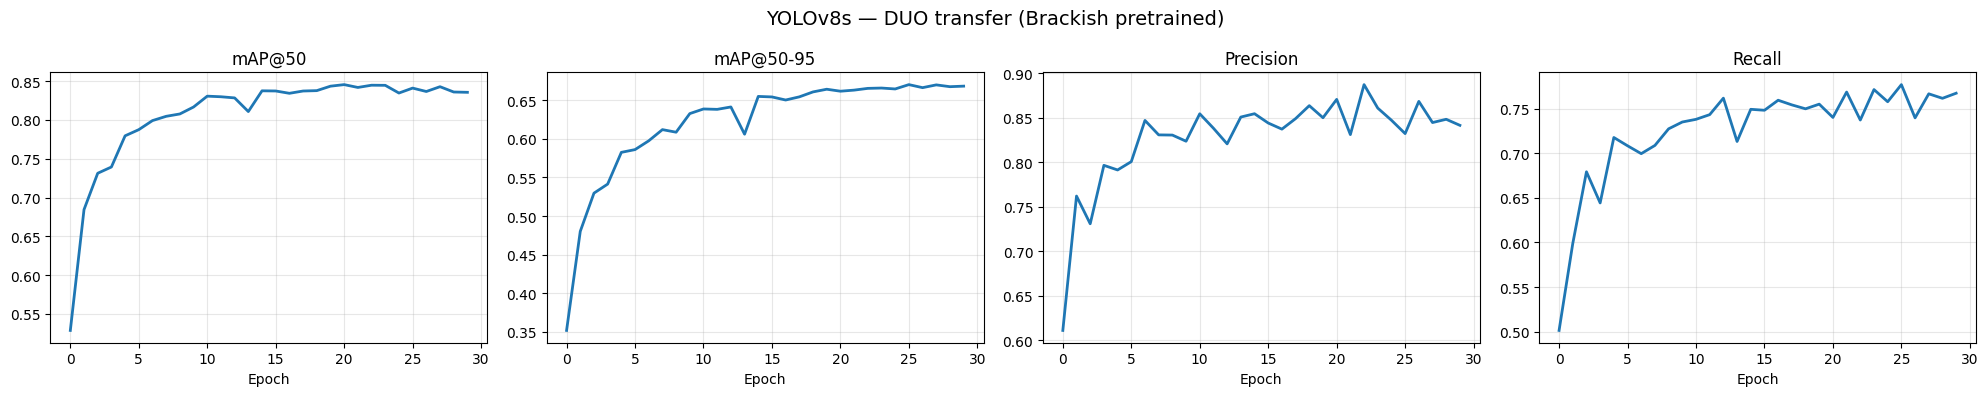


Best mAP@50:    0.8455  (epoch 21)
Best mAP@50-95: 0.6703  (epoch 26)


In [5]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

candidates = sorted(
    Path("runs/detect/runs/duo_yolov8s").glob("transfer*/results.csv"),
    key=lambda p: p.stat().st_mtime,
)
if not candidates:
    raise FileNotFoundError("results.csv не найден — возможно, обучение упало.")
RESULTS_CSV = candidates[-1]
print(f"Reading: {RESULTS_CSV}")

df = pd.read_csv(RESULTS_CSV, skipinitialspace=True)

metrics = {
    "mAP@50":    "metrics/mAP50(B)",
    "mAP@50-95": "metrics/mAP50-95(B)",
    "Precision": "metrics/precision(B)",
    "Recall":    "metrics/recall(B)",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (title, col) in zip(axes, metrics.items()):
    ax.plot(df[col], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)

plt.suptitle("YOLOv8s — DUO transfer (Brackish pretrained)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nBest mAP@50:    {df[metrics['mAP@50']].max():.4f}  (epoch {df[metrics['mAP@50']].argmax() + 1})")
print(f"Best mAP@50-95: {df[metrics['mAP@50-95']].max():.4f}  (epoch {df[metrics['mAP@50-95']].argmax() + 1})")

## Evaluate on DUO test set

In [6]:
weights_candidates = sorted(
    Path("runs/detect/runs/duo_yolov8s").glob("transfer*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)
WEIGHTS = weights_candidates[-1]
print(f"Using: {WEIGHTS}")

best = YOLO(str(WEIGHTS))

metrics = best.val(
    data="configs/dataset_duo.yaml",
    split="test",
    batch=1,
    device=0,
    plots=True,
)

print(f"mAP@50:      {metrics.box.map50:.4f}")
print(f"mAP@50-95:   {metrics.box.map:.4f}")
print(f"Precision:   {metrics.box.mp:.4f}")
print(f"Recall:      {metrics.box.mr:.4f}")

print(f"\nInference speed: {metrics.speed}")

print("\nPer-class AP@50:")
for i, name in metrics.names.items():
    print(f"  {name:12s}  {metrics.box.ap50[i]:.4f}")

Using: runs\detect\runs\duo_yolov8s\transfer3\weights\best.pt
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 4.38.8 ms, read: 5.33.2 MB/s, size: 70.7 KB)
val: Scanning D:\Slermo\Programming\Python\yolo_marine\data\DUO\yolo\labels\test.cache... 1111 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1111/1111  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1111/1111 68.6it/s 16.2s0.1s
                   all       1111      10517      0.809      0.775      0.833      0.653
           holothurian        490       1079      0.793      0.797      0.851      0.635
               echinus        967       7201      0.887       0.84      0.911      0.748
               scallop         78        217      0.677        0.6      0.649      0.486
              starfish  